Part A
Linear Fit -> MSE: 4.1470, R-Squared: 0.4960
Cubic Fit -> MSE: 2.1970, R-Squared: 0.7330
Decision: Cubic is the better fit.


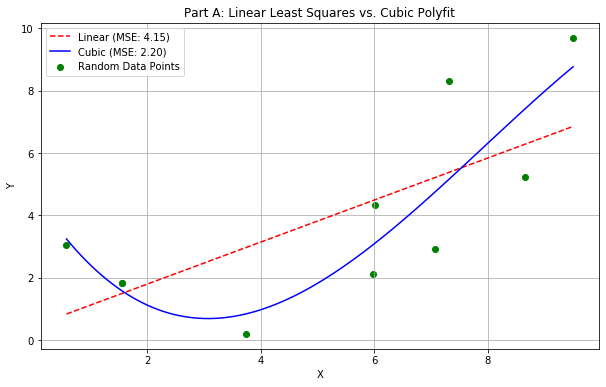


Part B
Degree 1 (Underfit) -> MSE: 4.1470, R-Squared: 0.4960
Degree 3  -> MSE: 2.1970, R-Squared: 0.7330
Degree 6  -> MSE: 1.5704, R-Squared: 0.8092
Degree 9 (Overfit) -> MSE: 0.0000, R-Squared: 1.0000


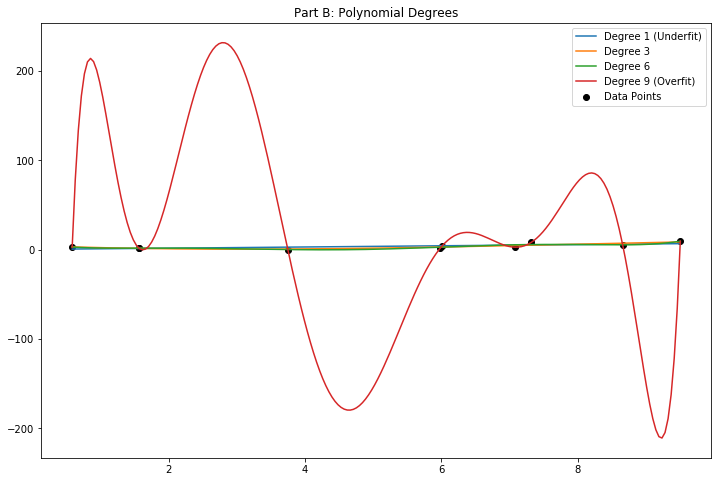


Part C
Vandermonde Cubic Fit -> MSE: 2.1970, R-Squared: 0.7330


(2.197036770175084, 0.7329973121218583)

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)
X_rand = np.random.rand(10) * 10
Y_rand = np.random.rand(10) * 10

def fit_evaluate(true_y, pred_y, label):
    mse = mean_squared_error(true_y, pred_y)
    r2 = r2_score(true_y, pred_y)
    print(f"{label} -> MSE: {mse:.4f}, R-Squared: {r2:.4f}")
    return mse, r2

print("Part A")

A_lin = np.vstack([X_rand, np.ones(len(X_rand))]).T
m, c = np.linalg.lstsq(A_lin, Y_rand, rcond=None)[0]
y_pred_lin = m * X_rand + c

coeff_p3 = np.polyfit(X_rand, Y_rand, 3)
p3_model = np.poly1d(coeff_p3)
y_pred_p3 = p3_model(X_rand)

mse_lin, r2_lin = fit_evaluate(Y_rand, y_pred_lin, "Linear Fit")
mse_p3, r2_p3 = fit_evaluate(Y_rand, y_pred_p3, "Cubic Fit")

bettermethod = "Cubic" if r2_p3 > r2_lin else "Linear"
print(f"Decision: {bettermethod} is the better fit.")

plt.figure(figsize=(10, 6))
plt.scatter(X_rand, Y_rand, color='green', label='Random Data Points')

x_smooth = np.linspace(min(X_rand), max(X_rand), 100)

plt.plot(x_smooth, m * x_smooth + c, 'r--', label=f'Linear (MSE: {mse_lin:.2f})')

plt.plot(x_smooth, p3_model(x_smooth), 'b-', label=f'Cubic (MSE: {mse_p3:.2f})')

plt.title('Part A: Linear Least Squares vs. Cubic Polyfit')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

print("\nPart B")

degree = [1, 3, 6, 9]
plt.figure(figsize=(12, 8))
plt.scatter(X_rand, Y_rand, color='black', label='Data Points')

x_plot = np.linspace(min(X_rand), max(X_rand), 200)

for d in degree:
    coeffs = np.polyfit(X_rand, Y_rand, d)
    model = np.poly1d(coeffs)
    pred_y = model(X_rand)
    
    status = ""
    if d == 1: status = "(Underfit)"
    if d == 9: status = "(Overfit)"
    
    fit_evaluate(Y_rand, pred_y, f"Degree {d} {status}")
    plt.plot(x_plot, model(x_plot), label=f'Degree {d} {status}')

plt.title("Part B: Polynomial Degrees")
plt.legend()
plt.show()

print("\nPart C")


degree = 3
V = np.vander(X_rand, degree + 1, increasing=True)

VT_V = np.dot(V.T, V)
VT_y = np.dot(V.T, Y_rand)
coeffs_v = np.linalg.solve(VT_V, VT_y)

poly_v = np.poly1d(coeffs_v[::-1])
y_pred_v = poly_v(X_rand)

fit_evaluate(Y_rand, y_pred_v, "Vandermonde Cubic Fit")